In [12]:
# =========================================================
# CÉLULA 0 — Config do projeto (Drive público)
# =========================================================
FILE_ID = "1hmaVYW7scJdfcmiPIKJ1_1RwWJt1V7Ci"
DATA_DIR = "/content/data"
DATA_PATH = f"{DATA_DIR}/dataset"

import os
os.makedirs(DATA_DIR, exist_ok=True)
print("OK:", DATA_DIR)


OK: /content/data


In [13]:
# =========================================================
# CÉLULA 1 — Download robusto do Google Drive (público)
# =========================================================
!pip -q install gdown

import gdown, os, glob

# Baixa com nome "dataset" (extensão pode variar)
url = f"https://drive.google.com/uc?id={FILE_ID}"
out = DATA_PATH
gdown.download(url, out, quiet=False)

# Se o Drive retornar arquivo com extensão, detecta
candidates = glob.glob(f"{DATA_DIR}/*")
print("Arquivos em data/:", candidates)


Downloading...
From: https://drive.google.com/uc?id=1hmaVYW7scJdfcmiPIKJ1_1RwWJt1V7Ci
To: /content/data/dataset
100%|██████████| 34.8k/34.8k [00:00<00:00, 46.4MB/s]

Arquivos em data/: ['/content/data/dataset']


In [14]:
# =========================================================
# CÉLULA 2 — Leitura automática (CSV/Excel) + detecção
# =========================================================
import pandas as pd
import os, glob

# tenta achar o arquivo baixado (dataset ou dataset.ext)
files = sorted(glob.glob(f"{DATA_DIR}/dataset*"))
if not files:
    raise FileNotFoundError("Não encontrei o arquivo baixado em /content/data.")

path = files[0]
print("Usando:", path)

# heurística por extensão; se não tiver, tenta csv primeiro
ext = os.path.splitext(path)[1].lower()

if ext in [".xlsx", ".xls"]:
    df = pd.read_excel(path)
else:
    try:
        df = pd.read_csv(path)
    except Exception:
        # fallback: tenta excel
        df = pd.read_excel(path)

print(df.shape)
df.head()


Usando: /content/data/dataset
(239, 62)


,Unnamed: 0,Student ID,"1.If the radius of earth were shrink by 1%, its mass remains the same, the acceleration due to gravity on the surface of earth would",2.A cable that can support a load W is cut into two equal parts. The maximum load can be supported by either part is,3.Boiling water is changing into steam. Under this condition the specific heat of water is,4.A difference of temperature of 25°C is equivalent to adifference to,5.Air bubble inside water appear silvery white due to,6.Sound wave do not show the phenomenon of,7.The heating element of an electric heater should be made with a material which should be,8.Equal charges are given to two surfaces of different radii. The potential will be,...,51.Diligent:,52.Mitigate:,53.Erotic:,54.I am with you ….... what you say,55.I parted ..... him at the college gate.,56.Why have you broken ..... with your friend.,57. It ..... the people who matter.,58.He did nothing but ….....,59.It is no good.... over the spilt milk.,60.She will wash up before she .... to bed.
0,0,3402.0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,1,0,0,1
1,1,2179.0,1,1,1,1,0,0,0,0,...,0,0,1,0,1,1,1,1,1,1
2,2,1061.0,1,0,1,0,0,0,1,1,...,0,1,0,0,0,1,1,0,1,1
3,3,2781.0,1,1,1,0,0,1,0,0,...,0,0,0,0,1,1,1,1,0,1
4,4,3688.0,1,0,1,0,1,1,0,0,...,0,0,0,0,1,1,1,0,0,0


In [15]:
# =========================================================
# CÉLULA 3 — Normalização para matriz 0/1 (respostas dicotômicas)
# Ajuste mínimo: define quais colunas são itens.
# =========================================================
import numpy as np

# Estratégia default:
# - assume que colunas numéricas com valores {0,1} são itens
num_cols = df.select_dtypes(include=["number", "bool"]).columns.tolist()

def is_binary(s):
    vals = pd.Series(s).dropna().unique()
    return set(vals).issubset({0, 1, True, False})

item_cols = [c for c in num_cols if is_binary(df[c])]

# Se seu dataset tiver colunas de ID/metadata numéricas binárias, remova aqui manualmente:
# item_cols = [c for c in item_cols if c not in ["id","gender",...]]

if len(item_cols) < 5:
    raise ValueError(f"Detectei poucos itens binários ({len(item_cols)}). "
                     "Provavelmente seus itens não estão em 0/1. "
                     "Me diga o formato (ex.: alternativa marcada + gabarito) que eu ajusto.")

Y = df[item_cols].astype(int).to_numpy()
N, J = Y.shape

print(f"Matriz Y: {Y.shape} | Pessoas={N} | Itens={J}")
print("Taxa média de acerto:", Y.mean().round(3))
print("Itens:", item_cols[:10], "..." if len(item_cols) > 10 else "")


Matriz Y: (239, 60) | Pessoas=239 | Itens=60
Taxa média de acerto: 0.422
Itens: ['1.If the radius of earth were shrink by 1%, its mass remains the same, the acceleration due to gravity on the surface of earth would', '2.A cable that can support a load W is cut into two equal parts. The maximum load can be supported by either part is', '3.Boiling water is changing into steam. Under this condition the specific heat of water is', '4.A difference of temperature of 25°C is equivalent to adifference to', '5.Air bubble inside water appear silvery white due to', '6.Sound wave do not show the phenomenon of', '7.The heating element of an electric heater should be made with a material which should be', '8.Equal charges are given to two surfaces of different radii. The potential will be', '9.Wavelength of matter wave is independent of', '10.When we apply reverse bias to a junction diode it'] ...


In [16]:
# =========================================================
# CÉLULA 4 — Instalar stack Bayes/IRT (PyMC)
# =========================================================
!pip -q install "pymc>=5" arviz

import pymc as pm
import arviz as az
import numpy as np


In [22]:
# =========================================================
# CÉLULA 5 — Modelo Rasch (1PL)
# P(Y_ij=1) = sigmoid(theta_i - b_j)
# =========================================================
coords = {"person": np.arange(N), "item": np.arange(J)}

with pm.Model(coords=coords) as rasch:
    theta = pm.Normal("theta", 0, 1, dims="person")
    b = pm.Normal("b", 0, 1, dims="item")

    # identificação (centraliza b)
    b_centered = b - pm.math.mean(b)

    eta = theta[:, None] - b_centered[None, :]
    p = pm.Deterministic("p", pm.math.sigmoid(eta), dims=("person", "item"))

    y = pm.Bernoulli("y", p=p, observed=Y, dims=("person", "item"))

    idata_rasch = pm.sample(
        draws=1000, tune=1000, chains=2, target_accept=0.9, random_seed=42,
        idata_kwargs={"log_likelihood": True},
    )

az.summary(idata_rasch, var_names=["b", "theta"]).head()


Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b[0],-1.081,0.189,-1.419,-0.736,0.012,0.007,244.0,477.0,1.01
b[1],-0.170,0.190,-0.526,0.190,0.013,0.009,237.0,378.0,1.01
b[2],-0.169,0.181,-0.508,0.170,0.012,0.007,215.0,349.0,1.01
b[3],-0.065,0.186,-0.397,0.327,0.013,0.008,224.0,419.0,1.01
b[4],-0.542,0.182,-0.884,-0.191,0.012,0.007,230.0,400.0,1.01


In [23]:
# =========================================================
# CÉLULA 6 (FINAL) — 2PL estável e rápido (portfólio Colab)
# 2 chains | 1500 tune + 1500 draws | log_likelihood embutido (LOO pronto)
# cores=1 para estabilidade (evita bug do Colab); se quiser mais rápido, troque para cores=2
# =========================================================
import pymc as pm
import arviz as az
import numpy as np

coords = {"person": np.arange(N), "item": np.arange(J)}

with pm.Model(coords=coords) as m2pl:
    theta = pm.Normal("theta", 0, 1, dims="person")
    b = pm.Normal("b", 0, 1, dims="item")

    # discriminação (prior firme): evita a inflado e estabiliza inferência
    a = pm.LogNormal("a", 0.0, 0.30, dims="item")

    # identificação: centraliza b (média zero)
    b_centered = b - pm.math.mean(b)

    eta = a[None, :] * (theta[:, None] - b_centered[None, :])
    p = pm.Deterministic("p", pm.math.sigmoid(eta), dims=("person", "item"))

    y = pm.Bernoulli("y", p=p, observed=Y, dims=("person", "item"))

    idata_2pl = pm.sample(
        draws=1500,
        tune=1500,
        chains=2,
        cores=1,                 # <- estável no Colab. Se estiver ok, pode usar cores=2.
        target_accept=0.92,
        random_seed=42,
        idata_kwargs={"log_likelihood": True},
    )

# Resumo rápido (sanity check)
summ = az.summary(idata_2pl, var_names=["a", "b"])
display(summ.head())
print("Divergences:", int(idata_2pl.sample_stats["diverging"].sum()))
print("Max r_hat (a,b):", float(np.nanmax(summ["r_hat"])))


Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[0],0.783,0.164,0.489,1.089,0.003,0.003,3420.0,2340.0,1.0
a[1],0.732,0.151,0.451,0.999,0.002,0.003,3846.0,2303.0,1.0
a[2],1.369,0.251,0.893,1.828,0.004,0.005,3948.0,1844.0,1.0
a[3],1.868,0.322,1.233,2.433,0.005,0.006,3841.0,2382.0,1.0
a[4],0.754,0.162,0.449,1.045,0.003,0.003,3353.0,2094.0,1.0


Divergences: 0
Max r_hat (a,b): 1.01


In [24]:
# CÉLULA 7 — Comparação (LOO)
loo_rasch = az.loo(idata_rasch, pointwise=True)
loo_2pl   = az.loo(idata_2pl,   pointwise=True)

cmp = az.compare(
    {"Rasch": idata_rasch, "2PL": idata_2pl},
    method="BB-pseudo-BMA",
    ic="loo"
)
cmp


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
2PL,0,-8908.978122,306.394152,0.000000,1.000000e+00,47.154761,0.000000,False,log
Rasch,1,-8995.952773,282.757405,86.974651,5.556965e-28,47.611176,9.161029,False,log


In [25]:
# =========================================================
# CÉLULA 8 — Tabela de calibração + ranking (2PL)
# =========================================================
import pandas as pd

a_post = idata_2pl.posterior["a"].mean(("chain","draw")).values
b_post = idata_2pl.posterior["b"].mean(("chain","draw")).values
b_post = b_post - b_post.mean()

a_sd = idata_2pl.posterior["a"].std(("chain","draw")).values
b_sd = idata_2pl.posterior["b"].std(("chain","draw")).values

calib = pd.DataFrame({
    "item": item_cols,
    "a": a_post,
    "a_sd": a_sd,
    "b": b_post,
    "b_sd": b_sd,
    "p_value": Y.mean(axis=0)  # proporção de acertos por item (observado)
}).sort_values(["a"], ascending=False)

calib.head(10)


,item,a,a_sd,b,b_sd,p_value
39,40.The equation for quadratic expression havin...,2.074243,0.388106,-0.790596,0.156122,0.627615
3,4.A difference of temperature of 25°C is equiv...,1.867989,0.321581,-0.250272,0.151319,0.430962
35,36.There are 5 questions in each group A and B...,1.655900,0.306032,-0.631028,0.159970,0.560669
46,47.lim 5x² + 7x + 20 x →∞ 6x3 + 15x + 22,1.523771,0.297109,-0.925595,0.176525,0.644351
2,3.Boiling water is changing into steam. Under ...,1.368607,0.251013,-0.295784,0.166556,0.456067
38,39.Find the value of 1 + 3/1! + 5/2! + 7/3! +…...,1.307497,0.253152,-0.439862,0.166622,0.497908
19,20.Inorganic benzene is,1.235804,0.232032,0.340279,0.204439,0.301255
30,31.The function f(y) = sec [log(y2 + √ I + y2)...,1.176626,0.228549,-0.326096,0.177316,0.468619
24,25.Pick out the isoelectronic structures from ...,1.142535,0.214454,0.051452,0.194632,0.376569
13,14.Material used in suspension wire of moving ...,1.124325,0.208132,0.592402,0.232940,0.259414


In [26]:
# =========================================================
# CÉLULA 9A — Legenda curta + dicionário Item -> Enunciado
# =========================================================
import pandas as pd

# Gera nomes curtos: I01, I02, ...
short_names = [f"I{str(i+1).zfill(2)}" for i in range(len(item_cols))]

# Mapa curto -> enunciado completo (pra você usar em tabela no relatório)
map_short_to_full = dict(zip(short_names, item_cols))

# (Opcional) também o inverso: enunciado -> curto
map_full_to_short = dict(zip(item_cols, short_names))

# Tabela de referência (boa pra anexar no relatório)
item_ref = pd.DataFrame({
    "Item_curto": short_names,
    "Enunciado": item_cols,
    "a": a_post,
    "b": b_post
}).sort_values("a", ascending=False)

item_ref.head(10)


,Item_curto,Enunciado,a,b
39,I40,40.The equation for quadratic expression havin...,2.074243,-0.790596
3,I04,4.A difference of temperature of 25°C is equiv...,1.867989,-0.250272
35,I36,36.There are 5 questions in each group A and B...,1.655900,-0.631028
46,I47,47.lim 5x² + 7x + 20 x →∞ 6x3 + 15x + 22,1.523771,-0.925595
2,I03,3.Boiling water is changing into steam. Under ...,1.368607,-0.295784
38,I39,39.Find the value of 1 + 3/1! + 5/2! + 7/3! +…...,1.307497,-0.439862
19,I20,20.Inorganic benzene is,1.235804,0.340279
30,I31,31.The function f(y) = sec [log(y2 + √ I + y2)...,1.176626,-0.326096
24,I25,25.Pick out the isoelectronic structures from ...,1.142535,0.051452
13,I14,14.Material used in suspension wire of moving ...,1.124325,0.592402


In [29]:
# ── CÉLULA 9A_TIF — calcular theta_grid, ICC e TIF ───────────────────────────
import numpy as np

# Grid de habilidade
theta_grid = np.linspace(-4, 4, 400)

# Parâmetros posteriores médios do 2PL
a_mean = idata_2pl.posterior["a"].mean(("chain", "draw")).values
b_mean = idata_2pl.posterior["b"].mean(("chain", "draw")).values
b_mean = b_mean - b_mean.mean()

# ICC — curva característica do item
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

ICC = sigmoid(a_mean[None, :] * (theta_grid[:, None] - b_mean[None, :]))

# TIF — soma da informação de Fisher de cada item em cada θ
item_info = (a_mean[None, :] ** 2) * ICC * (1 - ICC)
TIF = item_info.sum(axis=1)

print(f"✓ theta_grid : {theta_grid.shape}")
print(f"✓ TIF shape  : {TIF.shape}")
print(f"✓ Pico TIF   : θ≈{theta_grid[np.argmax(TIF)]:.2f}  TIF≈{TIF.max():.2f}")

✓ theta_grid : (400,)
✓ TIF shape  : (400,)
✓ Pico TIF   : θ≈-0.37  TIF≈12.35


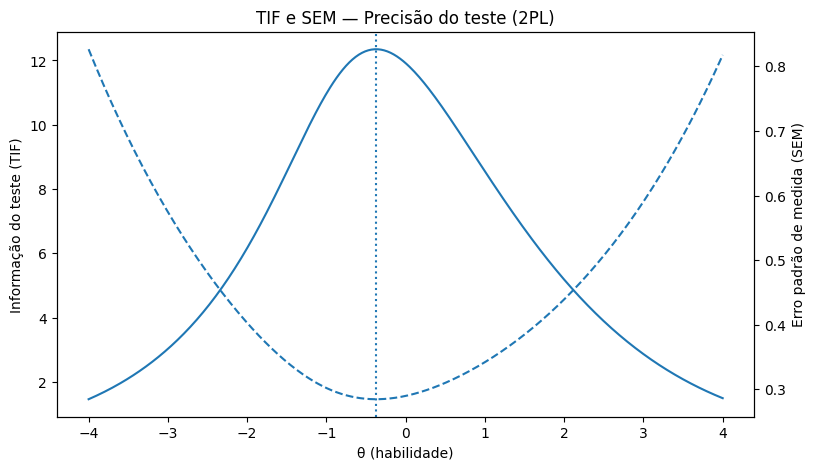

Pico TIF em θ≈-0.37 | TIF≈12.35 | SEM≈0.285


In [30]:
# =========================================================
# CÉLULA 9B — TIF + SEM no mesmo gráfico (2 eixos)
# SEM(θ) = 1/sqrt(TIF(θ))
# =========================================================
import numpy as np
import matplotlib.pyplot as plt

# evita divisão por zero
eps = 1e-12
SEM = 1 / np.sqrt(np.maximum(TIF, eps))

# onde o teste é mais preciso (pico de informação)
best_idx = np.argmax(TIF)

fig, ax1 = plt.subplots(figsize=(9,5))

# Eixo 1: TIF
ax1.plot(theta_grid, TIF)  # <-- estava faltando
ax1.axvline(theta_grid[best_idx], linestyle=":")
ax1.set_xlabel("θ (habilidade)")
ax1.set_ylabel("Informação do teste (TIF)")
ax1.set_title("TIF e SEM — Precisão do teste (2PL)")

# Eixo 2: SEM
ax2 = ax1.twinx()
ax2.plot(theta_grid, SEM, linestyle="--")
ax2.set_ylabel("Erro padrão de medida (SEM)")

plt.show()

print(f"Pico TIF em θ≈{theta_grid[best_idx]:.2f} | TIF≈{TIF[best_idx]:.2f} | SEM≈{SEM[best_idx]:.3f}")


Output()

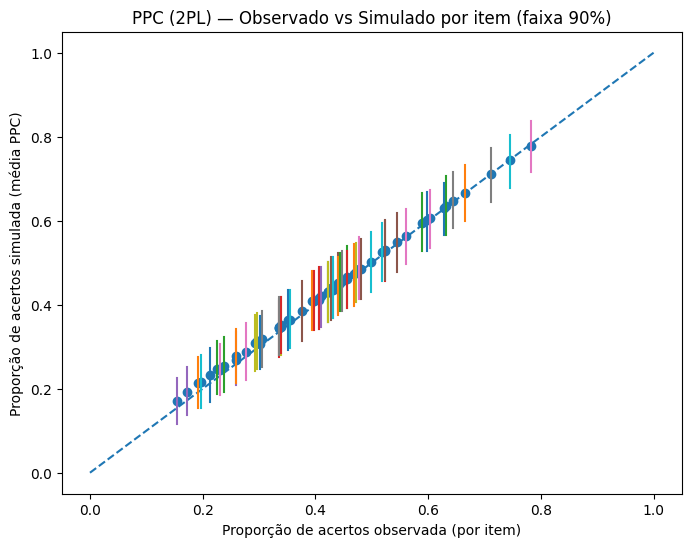

Itens fora da faixa 90%: 0 de 60
OK I22: p_obs=0.226 | p_ppc=0.248 [0.188, 0.314] | Δ=0.022
OK I34: p_obs=0.172 | p_ppc=0.193 [0.138, 0.251] | Δ=0.021
OK I21: p_obs=0.192 | p_ppc=0.213 [0.155, 0.276] | Δ=0.020
OK I51: p_obs=0.259 | p_ppc=0.279 [0.213, 0.343] | Δ=0.019
OK I49: p_obs=0.197 | p_ppc=0.216 [0.155, 0.280] | Δ=0.019
OK I30: p_obs=0.213 | p_ppc=0.232 [0.167, 0.297] | Δ=0.018
OK I52: p_obs=0.238 | p_ppc=0.255 [0.192, 0.322] | Δ=0.017
OK I54: p_obs=0.155 | p_ppc=0.171 [0.117, 0.226] | Δ=0.016
OK I48: p_obs=0.297 | p_ppc=0.313 [0.247, 0.381] | Δ=0.016
OK I38: p_obs=0.293 | p_ppc=0.309 [0.243, 0.377] | Δ=0.016


In [31]:
# =========================================================
# CÉLULA 11 — PPC rápido (2PL): p_item observado vs simulado
# =========================================================
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm

# 1) Gerar posterior predictive se ainda não existir
if not hasattr(idata_2pl, "posterior_predictive"):
    with m2pl:
        ppc = pm.sample_posterior_predictive(
            idata_2pl,
            var_names=["y"],
            random_seed=42
        )
    idata_2pl.extend(ppc)

# 2) Observado: proporção de acertos por item
p_obs = Y.mean(axis=0)  # (J,)

# 3) Simulado: proporção de acertos por item em cada draw
# y_ppc dims típicos: (chain, draw, person, item)
y_ppc = idata_2pl.posterior_predictive["y"].values

# achata chain+draw => S amostras
S = y_ppc.shape[0] * y_ppc.shape[1]
y_ppc_flat = y_ppc.reshape(S, y_ppc.shape[2], y_ppc.shape[3])  # (S, N, J)

p_sim = y_ppc_flat.mean(axis=1)               # (S, J) média em pessoas
p_sim_mean = p_sim.mean(axis=0)               # (J,)
p_sim_lo = np.quantile(p_sim, 0.05, axis=0)   # (J,)
p_sim_hi = np.quantile(p_sim, 0.95, axis=0)   # (J,)

# 4) Gráfico: Observado vs Simulado (com faixa 90%)
plt.figure(figsize=(8,6))
plt.plot([0,1],[0,1], linestyle="--")  # linha identidade
plt.scatter(p_obs, p_sim_mean)

# barras verticais (intervalo 90%)
for j in range(len(p_obs)):
    plt.plot([p_obs[j], p_obs[j]], [p_sim_lo[j], p_sim_hi[j]])

plt.xlabel("Proporção de acertos observada (por item)")
plt.ylabel("Proporção de acertos simulada (média PPC)")
plt.title("PPC (2PL) — Observado vs Simulado por item (faixa 90%)")
plt.show()

# 5) Diagnóstico objetivo: itens fora da faixa 90%
out = np.where((p_obs < p_sim_lo) | (p_obs > p_sim_hi))[0]
print(f"Itens fora da faixa 90%: {len(out)} de {len(p_obs)}")

# Mostra top 10 piores (distância absoluta)
dist = np.abs(p_obs - p_sim_mean)
top = np.argsort(-dist)[:10]
for j in top:
    flag = "⚠️" if j in out else "OK"
    print(f"{flag} {map_full_to_short[item_cols[j]] if 'map_full_to_short' in globals() else j}: "
          f"p_obs={p_obs[j]:.3f} | p_ppc={p_sim_mean[j]:.3f} "
          f"[{p_sim_lo[j]:.3f}, {p_sim_hi[j]:.3f}] | Δ={dist[j]:.3f}")


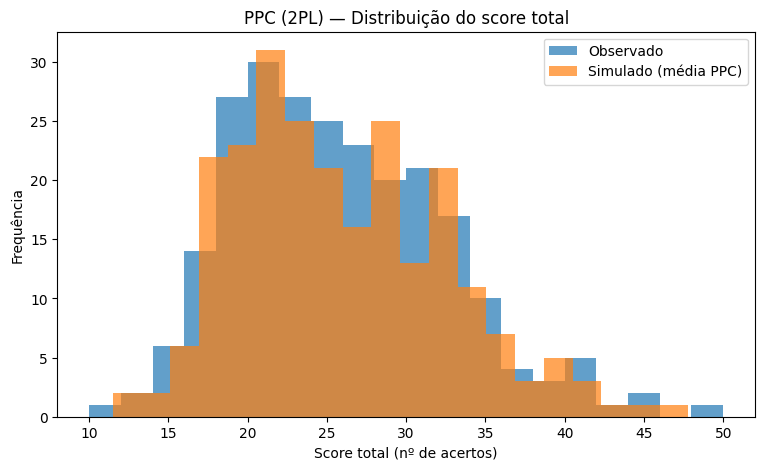

Cobertura 90% (score total): 1.000


In [34]:
# =========================================================
# CÉLULA 12 — PPC do score total (soma de acertos por pessoa)
# =========================================================
import numpy as np
import matplotlib.pyplot as plt

# Observado: score total por pessoa
score_obs = Y.sum(axis=1)

# Simulado: score total por pessoa em cada draw
y_ppc = idata_2pl.posterior_predictive["y"].values
S = y_ppc.shape[0] * y_ppc.shape[1]
y_ppc_flat = y_ppc.reshape(S, y_ppc.shape[2], y_ppc.shape[3])  # (S,N,J)
score_sim = y_ppc_flat.sum(axis=2)  # (S,N)

# intervalos por pessoa (opcional) e distribuição agregada
score_sim_mean = score_sim.mean(axis=0)
lo = np.quantile(score_sim, 0.05, axis=0)
hi = np.quantile(score_sim, 0.95, axis=0)

plt.figure(figsize=(9,5))
plt.hist(score_obs, bins=20, alpha=0.7, label="Observado")
plt.hist(score_sim_mean, bins=20, alpha=0.7, label="Simulado (média PPC)")
plt.xlabel("Score total (nº de acertos)")
plt.ylabel("Frequência")
plt.title("PPC (2PL) — Distribuição do score total")
plt.legend()
plt.show()

# cobertura simples: % pessoas com score observado dentro do intervalo 90% simulado
coverage = np.mean((score_obs >= lo) & (score_obs <= hi))
print(f"Cobertura 90% (score total): {coverage:.3f}")


Cobertura 50% (score esperado): 0.900 | Largura média: 4.36
Cobertura 90% (score esperado): 1.000 | Largura média: 10.59


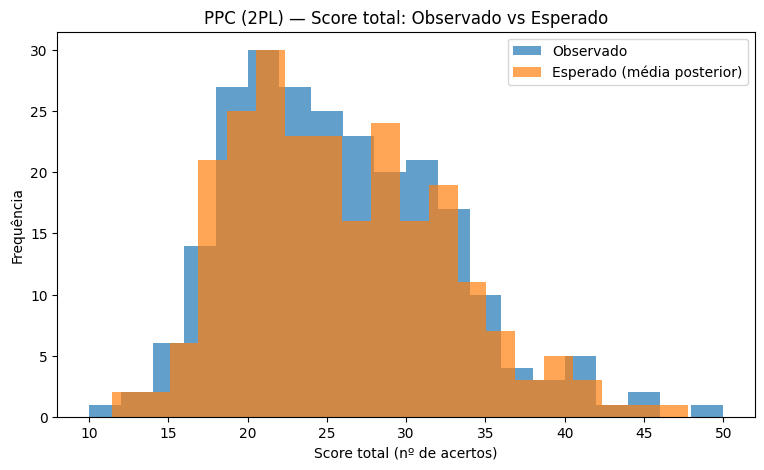

In [33]:
# =========================================================
# CÉLULA 12 (RECOMENDADA) — PPC do score total via score esperado (E[score])
# =========================================================
import numpy as np
import matplotlib.pyplot as plt

# Observado
score_obs = Y.sum(axis=1)

# p posterior: dims (chain, draw, person, item)
p_post = idata_2pl.posterior["p"].values
S = p_post.shape[0] * p_post.shape[1]
p_flat = p_post.reshape(S, p_post.shape[2], p_post.shape[3])  # (S, N, J)

# Score esperado por pessoa em cada draw
score_exp = p_flat.sum(axis=2)  # (S, N)

# Intervalos por pessoa
lo50, hi50 = np.quantile(score_exp, [0.25, 0.75], axis=0)
lo90, hi90 = np.quantile(score_exp, [0.05, 0.95], axis=0)

cov50 = np.mean((score_obs >= lo50) & (score_obs <= hi50))
cov90 = np.mean((score_obs >= lo90) & (score_obs <= hi90))

print(f"Cobertura 50% (score esperado): {cov50:.3f} | Largura média: {(hi50-lo50).mean():.2f}")
print(f"Cobertura 90% (score esperado): {cov90:.3f} | Largura média: {(hi90-lo90).mean():.2f}")

# Distribuição agregada: observado vs esperado
score_exp_mean = score_exp.mean(axis=0)

plt.figure(figsize=(9,5))
plt.hist(score_obs, bins=20, alpha=0.7, label="Observado")
plt.hist(score_exp_mean, bins=20, alpha=0.7, label="Esperado (média posterior)")
plt.xlabel("Score total (nº de acertos)")
plt.ylabel("Frequência")
plt.title("PPC (2PL) — Score total: Observado vs Esperado")
plt.legend()
plt.show()


In [35]:
# =========================================================
# CÉLULA 12B — Auditoria da cobertura (50%, 90%, 95%) + largura do intervalo
# =========================================================
import numpy as np

def coverage_for(alpha):
    lo = np.quantile(score_sim, (1-alpha)/2, axis=0)
    hi = np.quantile(score_sim, 1-(1-alpha)/2, axis=0)
    cov = np.mean((score_obs >= lo) & (score_obs <= hi))
    width = np.mean(hi - lo)
    return cov, width

for a in [0.50, 0.90, 0.95]:
    cov, width = coverage_for(a)
    print(f"Cobertura {int(a*100)}%: {cov:.3f} | Largura média do intervalo: {width:.2f} pontos")


Cobertura 50%: 0.996 | Largura média do intervalo: 6.48 pontos
Cobertura 90%: 1.000 | Largura média do intervalo: 15.62 pontos
Cobertura 95%: 1.000 | Largura média do intervalo: 18.60 pontos


MÉDIA score total — obs=25.30 | PPC90%=[25.30, 26.37] | PPC95%=[25.20, 26.46]
DP score total    — obs=6.74 | PPC90%=[7.65, 8.54] | PPC95%=[7.57, 8.61]


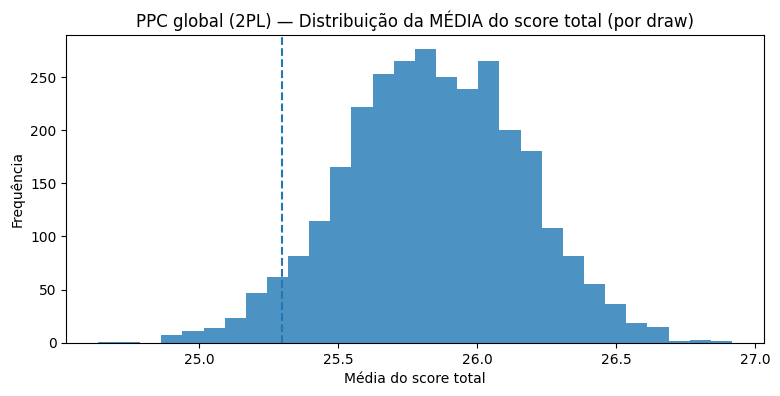

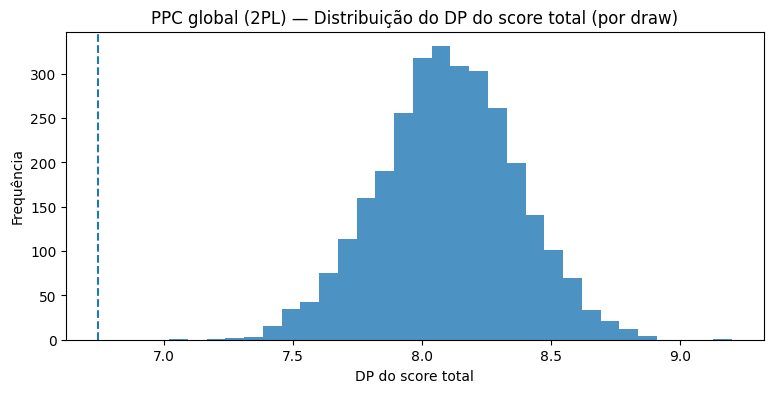

Veredito PPC90% | Média dentro? False | DP dentro? False


In [36]:
# =========================================================
# CÉLULA 13 — PPC GLOBAL (2PL): média e DP do score total por draw
# =========================================================
import numpy as np
import matplotlib.pyplot as plt

# Observado
score_obs = Y.sum(axis=1)
mu_obs = score_obs.mean()
sd_obs = score_obs.std(ddof=1)

# Simulado (por draw): usa posterior_predictive['y']
# Se não existir, gera rapidamente
import pymc as pm
if not hasattr(idata_2pl, "posterior_predictive"):
    with m2pl:
        ppc = pm.sample_posterior_predictive(idata_2pl, var_names=["y"], random_seed=42)
    idata_2pl.extend(ppc)

y_ppc = idata_2pl.posterior_predictive["y"].values  # (chain, draw, person, item)
S = y_ppc.shape[0] * y_ppc.shape[1]
y_ppc_flat = y_ppc.reshape(S, y_ppc.shape[2], y_ppc.shape[3])  # (S, N, J)

# Score total por pessoa e por draw
score_sim = y_ppc_flat.sum(axis=2)  # (S, N)

# Métricas globais por draw
mu_sim = score_sim.mean(axis=1)                 # (S,)
sd_sim = score_sim.std(axis=1, ddof=1)          # (S,)

# Intervalos preditivos globais (90% e 95%)
mu_lo90, mu_hi90 = np.quantile(mu_sim, [0.05, 0.95])
sd_lo90, sd_hi90 = np.quantile(sd_sim, [0.05, 0.95])

mu_lo95, mu_hi95 = np.quantile(mu_sim, [0.025, 0.975])
sd_lo95, sd_hi95 = np.quantile(sd_sim, [0.025, 0.975])

print(f"MÉDIA score total — obs={mu_obs:.2f} | PPC90%=[{mu_lo90:.2f}, {mu_hi90:.2f}] | PPC95%=[{mu_lo95:.2f}, {mu_hi95:.2f}]")
print(f"DP score total    — obs={sd_obs:.2f} | PPC90%=[{sd_lo90:.2f}, {sd_hi90:.2f}] | PPC95%=[{sd_lo95:.2f}, {sd_hi95:.2f}]")

# Visual 1: distribuição da média por draw
plt.figure(figsize=(9,4))
plt.hist(mu_sim, bins=30, alpha=0.8)
plt.axvline(mu_obs, linestyle="--")
plt.title("PPC global (2PL) — Distribuição da MÉDIA do score total (por draw)")
plt.xlabel("Média do score total")
plt.ylabel("Frequência")
plt.show()

# Visual 2: distribuição do DP por draw
plt.figure(figsize=(9,4))
plt.hist(sd_sim, bins=30, alpha=0.8)
plt.axvline(sd_obs, linestyle="--")
plt.title("PPC global (2PL) — Distribuição do DP do score total (por draw)")
plt.xlabel("DP do score total")
plt.ylabel("Frequência")
plt.show()

# Veredito objetivo: observado dentro do intervalo 90%?
ok_mu = (mu_obs >= mu_lo90) and (mu_obs <= mu_hi90)
ok_sd = (sd_obs >= sd_lo90) and (sd_obs <= sd_hi90)
print(f"Veredito PPC90% | Média dentro? {ok_mu} | DP dentro? {ok_sd}")


MÉDIA obs=25.30 | PPC90% (E[score])=[25.47, 26.21]
DP    obs=6.74 | PPC90% (E[score])=[6.97, 7.62]


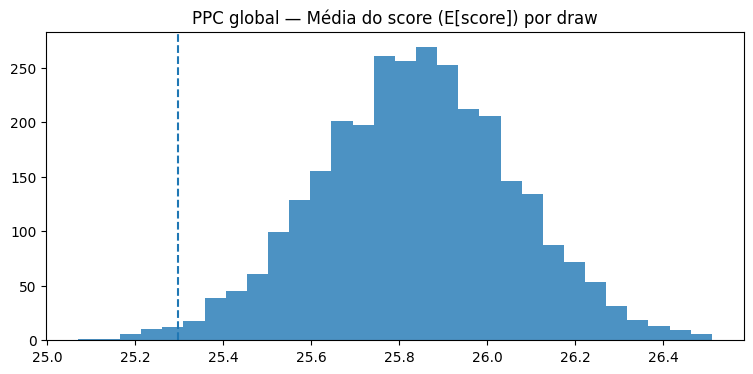

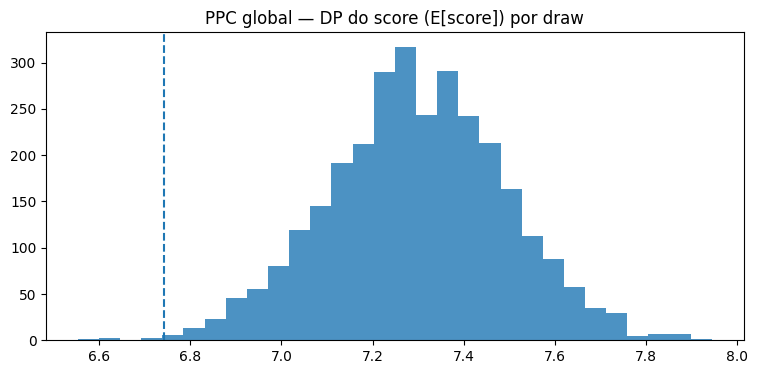

In [37]:
# =========================================================
# CÉLULA 13B — PPC GLOBAL via score esperado (E[score]) por draw
# =========================================================
import numpy as np
import matplotlib.pyplot as plt

score_obs = Y.sum(axis=1)
mu_obs = score_obs.mean()
sd_obs = score_obs.std(ddof=1)

p_post = idata_2pl.posterior["p"].values  # (chain, draw, person, item)
S = p_post.shape[0] * p_post.shape[1]
p_flat = p_post.reshape(S, p_post.shape[2], p_post.shape[3])  # (S,N,J)

# score esperado por pessoa e por draw
score_exp = p_flat.sum(axis=2)  # (S,N)

mu_exp = score_exp.mean(axis=1)
sd_exp = score_exp.std(axis=1, ddof=1)

mu_lo90, mu_hi90 = np.quantile(mu_exp, [0.05, 0.95])
sd_lo90, sd_hi90 = np.quantile(sd_exp, [0.05, 0.95])

print(f"MÉDIA obs={mu_obs:.2f} | PPC90% (E[score])=[{mu_lo90:.2f}, {mu_hi90:.2f}]")
print(f"DP    obs={sd_obs:.2f} | PPC90% (E[score])=[{sd_lo90:.2f}, {sd_hi90:.2f}]")

plt.figure(figsize=(9,4))
plt.hist(mu_exp, bins=30, alpha=0.8)
plt.axvline(mu_obs, linestyle="--")
plt.title("PPC global — Média do score (E[score]) por draw")
plt.show()

plt.figure(figsize=(9,4))
plt.hist(sd_exp, bins=30, alpha=0.8)
plt.axvline(sd_obs, linestyle="--")
plt.title("PPC global — DP do score (E[score]) por draw")
plt.show()


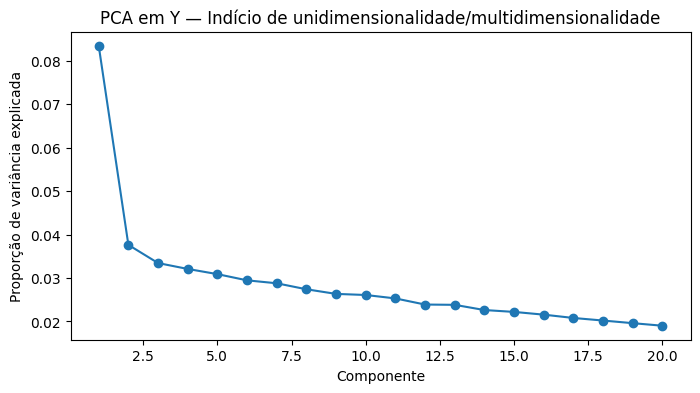

Top 5 variâncias explicadas: [0.0834 0.0376 0.0334 0.0321 0.0309]
Razão PC1/PC2: 2.2184490528035576


In [38]:
# =========================================================
# CÉLULA 14 — Diagnóstico rápido de unidimensionalidade (PCA em Y)
# =========================================================
import numpy as np
import matplotlib.pyplot as plt

# centraliza por item
Yc = Y - Y.mean(axis=0, keepdims=True)

# SVD (PCA)
U, S, Vt = np.linalg.svd(Yc, full_matrices=False)

# variância explicada
eig = S**2
var_exp = eig / eig.sum()

plt.figure(figsize=(8,4))
plt.plot(np.arange(1, 21), var_exp[:20], marker="o")
plt.xlabel("Componente")
plt.ylabel("Proporção de variância explicada")
plt.title("PCA em Y — Indício de unidimensionalidade/multidimensionalidade")
plt.show()

print("Top 5 variâncias explicadas:", np.round(var_exp[:5], 4))
print("Razão PC1/PC2:", float(var_exp[0]/var_exp[1]))


Média Q3 off-diagonal: -0.0152
Pares com Q3_adj >= 0.20: 2


,item_i,item_j,Q3_adj,Q3_raw,i,j
0,I36,I39,0.237198,0.222021,35,38
1,I03,I04,0.216638,0.201461,2,3


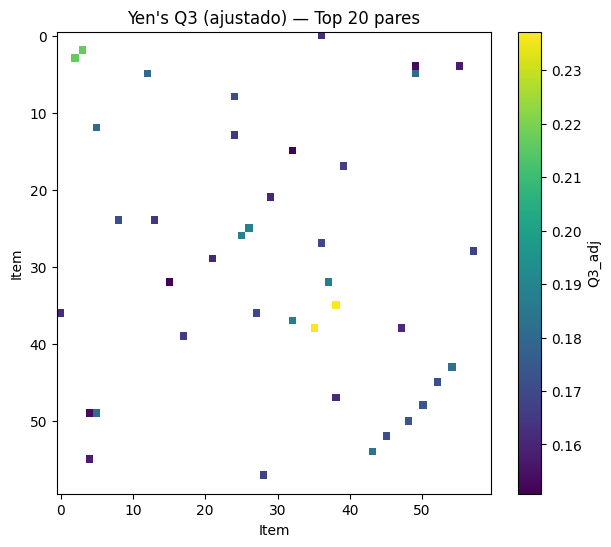

In [39]:
# =========================================================
# CÉLULA 15 — Yen’s Q3 (dependência local) usando resíduos do 2PL
# =========================================================
import numpy as np
import pandas as pd

# 1) Probabilidade prevista por pessoa×item (média posterior)
p_mean = idata_2pl.posterior["p"].mean(("chain", "draw")).values  # (N, J)

# 2) Resíduo padronizado: (y - p) / sqrt(p(1-p))
eps = 1e-9
den = np.sqrt(np.clip(p_mean * (1 - p_mean), eps, None))
R = (Y - p_mean) / den  # (N, J)

# 3) Q3 = correlação (Pearson) entre resíduos de itens
Q3 = np.corrcoef(R, rowvar=False)  # (J, J)
np.fill_diagonal(Q3, np.nan)

# 4) Estimativa do viés médio (às vezes subtraem a média dos off-diagonais)
off = Q3[~np.isnan(Q3)]
mean_off = np.nanmean(off)
Q3_adj = Q3 - mean_off
np.fill_diagonal(Q3_adj, np.nan)

print(f"Média Q3 off-diagonal: {mean_off:.4f}")

# 5) Extrair pares top (maiores Q3 ajustados)
pairs = []
for i in range(Q3_adj.shape[0]):
    for j in range(i+1, Q3_adj.shape[1]):
        pairs.append((i, j, Q3_adj[i, j], Q3[i, j]))

pairs_df = pd.DataFrame(pairs, columns=["i", "j", "Q3_adj", "Q3_raw"])
pairs_df = pairs_df.sort_values("Q3_adj", ascending=False).reset_index(drop=True)

# 6) Defina um limiar (regra prática: 0.20 ou 0.30 para sinal forte)
TH = 0.20
flag_df = pairs_df[pairs_df["Q3_adj"] >= TH].copy()

print(f"Pares com Q3_adj >= {TH:.2f}: {len(flag_df)}")

# 7) Anexar nomes curtos se existirem
if "map_full_to_short" in globals():
    flag_df["item_i"] = [map_full_to_short[item_cols[i]] for i in flag_df["i"]]
    flag_df["item_j"] = [map_full_to_short[item_cols[j]] for j in flag_df["j"]]
else:
    flag_df["item_i"] = flag_df["i"].astype(str)
    flag_df["item_j"] = flag_df["j"].astype(str)

# Mostra top 15 suspeitos
cols_show = ["item_i", "item_j", "Q3_adj", "Q3_raw", "i", "j"]
display(flag_df[cols_show].head(15))

# 8) (Opcional) Heatmap simples dos maiores Q3_adj (sem seaborn)
import matplotlib.pyplot as plt

top_k = 20
top_pairs = pairs_df.head(top_k)

# cria matriz vazia só com top_k para visual
M = np.zeros_like(Q3_adj)
M[:] = np.nan
for _, row in top_pairs.iterrows():
    i, j = int(row["i"]), int(row["j"])
    M[i, j] = row["Q3_adj"]
    M[j, i] = row["Q3_adj"]

plt.figure(figsize=(7,6))
plt.imshow(M, aspect="auto")
plt.title(f"Yen's Q3 (ajustado) — Top {top_k} pares")
plt.colorbar(label="Q3_adj")
plt.xlabel("Item")
plt.ylabel("Item")
plt.show()


Pares Q3_adj >= 0.20: 2
 - 36.There are 5 questions in each gr...  <->  39.Find the value of 1 + 3/1! + 5/2... | Q3_adj=0.237
 - 3.Boiling water is changing into st...  <->  4.A difference of temperature of 25... | Q3_adj=0.217

Itens marcados para remoção (menor a em cada par): 2
 - 3.Boiling water is changing into steam. Under this condition the specific heat of water is
 - 39.Find the value of 1 + 3/1! + 5/2! + 7/3! +…...+ ∞

Y original: (239, 60) | Y reduzido: (239, 58)


Output()


Resumo (a,b) — reduzido:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[0],0.773,0.168,0.485,1.097,0.002,0.003,4798.0,2417.0,1.0
a[1],0.745,0.159,0.457,1.032,0.002,0.003,4446.0,2418.0,1.0
a[2],1.762,0.328,1.172,2.361,0.005,0.006,3865.0,2293.0,1.0
a[3],0.778,0.167,0.456,1.067,0.003,0.003,4282.0,2484.0,1.0
a[4],1.082,0.226,0.697,1.532,0.003,0.004,4229.0,2384.0,1.0



PPC global via E[score] (dataset reduzido)
MÉDIA obs=24.34 | PPC90%=[24.54, 25.25] | dentro? False
DP    obs=6.35 | PPC90%=[6.56, 7.21] | dentro? False


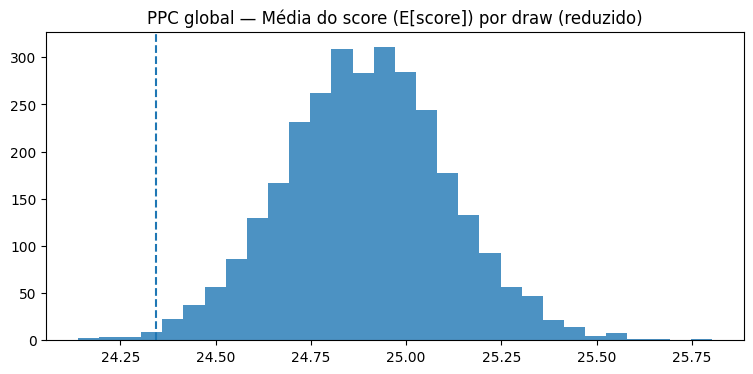

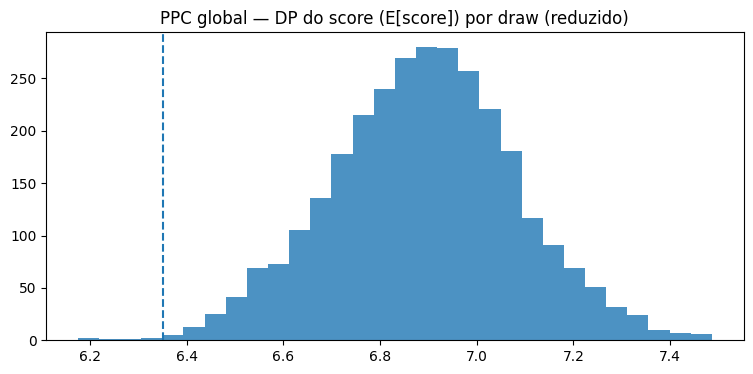

In [40]:
# =========================================================
# CÉLULA 16 — Reestimar 2PL removendo 1 item por par (menor a) + PPC global
# =========================================================
import numpy as np
import pandas as pd
import pymc as pm
import matplotlib.pyplot as plt

# ---------- 1) Recuperar a e mapa item ----------
a_mean = idata_2pl.posterior["a"].mean(("chain","draw")).values  # (J,)
a_by_item = dict(zip(item_cols, a_mean))

# ---------- 2) Obter pares suspeitos (Q3) ----------
# Se você já tem flag_df do Q3, ele usa. Senão, recalcula.
TH = 0.20

if "flag_df" not in globals():
    # Recalcula Q3 rápido (mesma lógica da célula anterior)
    p_mean = idata_2pl.posterior["p"].mean(("chain", "draw")).values  # (N,J)
    eps = 1e-9
    den = np.sqrt(np.clip(p_mean * (1 - p_mean), eps, None))
    R = (Y - p_mean) / den
    Q3 = np.corrcoef(R, rowvar=False)
    np.fill_diagonal(Q3, np.nan)
    mean_off = np.nanmean(Q3[~np.isnan(Q3)])
    Q3_adj = Q3 - mean_off
    np.fill_diagonal(Q3_adj, np.nan)

    pairs = []
    J = Q3_adj.shape[0]
    for i in range(J):
        for j in range(i+1, J):
            pairs.append((i,j,Q3_adj[i,j],Q3[i,j]))
    pairs_df = pd.DataFrame(pairs, columns=["i","j","Q3_adj","Q3_raw"]).sort_values("Q3_adj", ascending=False)
    flag_df = pairs_df[pairs_df["Q3_adj"] >= TH].copy().reset_index(drop=True)

# Constrói pares como nomes de itens
pairs_items = [(item_cols[int(r.i)], item_cols[int(r.j)], float(r.Q3_adj)) for r in flag_df.itertuples()]

print(f"Pares Q3_adj >= {TH:.2f}: {len(pairs_items)}")
for (it1, it2, q3) in pairs_items[:10]:
    print(f" - {it1[:35]}...  <->  {it2[:35]}... | Q3_adj={q3:.3f}")

# ---------- 3) Escolher item a remover em cada par (menor a) ----------
to_remove = set()
for it1, it2, q3 in pairs_items:
    a1 = a_by_item[it1]
    a2 = a_by_item[it2]
    drop = it1 if a1 <= a2 else it2
    to_remove.add(drop)

print("\nItens marcados para remoção (menor a em cada par):", len(to_remove))
for it in list(to_remove)[:10]:
    print(" -", it)

# ---------- 4) Criar dataset reduzido ----------
keep_mask = [c not in to_remove for c in item_cols]
item_cols_red = [c for c in item_cols if c not in to_remove]
Y_red = Y[:, keep_mask]

N_red, J_red = Y_red.shape
print(f"\nY original: {Y.shape} | Y reduzido: {Y_red.shape}")

# ---------- 5) Reestimar 2PL no dataset reduzido ----------
coords_red = {"person": np.arange(N_red), "item": np.arange(J_red)}

with pm.Model(coords=coords_red) as m2pl_red:
    theta = pm.Normal("theta", 0, 1, dims="person")
    b = pm.Normal("b", 0, 1, dims="item")
    a = pm.LogNormal("a", 0.0, 0.30, dims="item")  # prior firme (como você usou)

    b_centered = b - pm.math.mean(b)
    eta = a[None, :] * (theta[:, None] - b_centered[None, :])
    p = pm.Deterministic("p", pm.math.sigmoid(eta), dims=("person","item"))

    y = pm.Bernoulli("y", p=p, observed=Y_red, dims=("person","item"))

    idata_2pl_red = pm.sample(
        draws=1500, tune=1500,
        chains=2, cores=2,
        target_accept=0.92,
        random_seed=42,
        idata_kwargs={"log_likelihood": True},
    )

print("\nResumo (a,b) — reduzido:")
display(pm.stats.summary(idata_2pl_red, var_names=["a","b"]).head())

# ---------- 6) PPC GLOBAL via E[score] (mais justo) ----------
score_obs_red = Y_red.sum(axis=1)
mu_obs = score_obs_red.mean()
sd_obs = score_obs_red.std(ddof=1)

p_post = idata_2pl_red.posterior["p"].values  # (chain, draw, person, item)
S = p_post.shape[0] * p_post.shape[1]
p_flat = p_post.reshape(S, p_post.shape[2], p_post.shape[3])  # (S,N,J)

score_exp = p_flat.sum(axis=2)  # (S,N)
mu_exp = score_exp.mean(axis=1)
sd_exp = score_exp.std(axis=1, ddof=1)

mu_lo90, mu_hi90 = np.quantile(mu_exp, [0.05, 0.95])
sd_lo90, sd_hi90 = np.quantile(sd_exp, [0.05, 0.95])

print("\nPPC global via E[score] (dataset reduzido)")
print(f"MÉDIA obs={mu_obs:.2f} | PPC90%=[{mu_lo90:.2f}, {mu_hi90:.2f}] | dentro? {mu_lo90 <= mu_obs <= mu_hi90}")
print(f"DP    obs={sd_obs:.2f} | PPC90%=[{sd_lo90:.2f}, {sd_hi90:.2f}] | dentro? {sd_lo90 <= sd_obs <= sd_hi90}")

plt.figure(figsize=(9,4))
plt.hist(mu_exp, bins=30, alpha=0.8)
plt.axvline(mu_obs, linestyle="--")
plt.title("PPC global — Média do score (E[score]) por draw (reduzido)")
plt.show()

plt.figure(figsize=(9,4))
plt.hist(sd_exp, bins=30, alpha=0.8)
plt.axvline(sd_obs, linestyle="--")
plt.title("PPC global — DP do score (E[score]) por draw (reduzido)")
plt.show()

# ---------- 7) (Opcional) PPC global via posterior_predictive y ----------
# (mais ruidoso, mas às vezes você quer mostrar também)
do_ppc_y = False
if do_ppc_y:
    if not hasattr(idata_2pl_red, "posterior_predictive"):
        with m2pl_red:
            ppc = pm.sample_posterior_predictive(idata_2pl_red, var_names=["y"], random_seed=42)
        idata_2pl_red.extend(ppc)

    y_ppc = idata_2pl_red.posterior_predictive["y"].values
    S = y_ppc.shape[0] * y_ppc.shape[1]
    y_flat = y_ppc.reshape(S, y_ppc.shape[2], y_ppc.shape[3])
    score_sim = y_flat.sum(axis=2)

    mu_sim = score_sim.mean(axis=1)
    sd_sim = score_sim.std(axis=1, ddof=1)

    mu_lo90, mu_hi90 = np.quantile(mu_sim, [0.05, 0.95])
    sd_lo90, sd_hi90 = np.quantile(sd_sim, [0.05, 0.95])

    print("\nPPC global via y (ruidoso) — reduzido")
    print(f"MÉDIA obs={mu_obs:.2f} | PPC90%=[{mu_lo90:.2f}, {mu_hi90:.2f}]")
    print(f"DP    obs={sd_obs:.2f} | PPC90%=[{sd_lo90:.2f}, {sd_hi90:.2f}]")


In [41]:
# =========================================================
# CÉLULA FINAL — Executive Summary TRI (Rasch vs 2PL + Validações)
# =========================================================
import numpy as np
import arviz as az
import pandas as pd

print("=======================================")
print("EXECUTIVE SUMMARY — TRI (Rasch vs 2PL)")
print("=======================================\n")

# ---------- 0) Dados ----------
N, J = Y.shape
p_bar = float(Y.mean())
print(f"Dados: N={N} pessoas | J={J} itens | taxa média de acerto={p_bar:.3f}\n")

# ---------- 1) LOO: Rasch vs 2PL ----------
try:
    cmp = az.compare({"Rasch": idata_rasch, "2PL": idata_2pl}, method="BB-pseudo-BMA", ic="loo")
    elpd_r = float(cmp.loc["Rasch", "elpd_loo"])
    elpd_2 = float(cmp.loc["2PL", "elpd_loo"])
    w_r = float(cmp.loc["Rasch", "weight"])
    w_2 = float(cmp.loc["2PL", "weight"])
    print("1) Comparação de modelos (LOO)")
    print(f"   elpd_loo 2PL  : {elpd_2:.2f} | peso: {w_2:.3f}")
    print(f"   elpd_loo Rasch: {elpd_r:.2f} | peso: {w_r:.3f}")
    print(f"   Δelpd (2PL - Rasch): {(elpd_2-elpd_r):.2f}\n")
except Exception as e:
    print("1) LOO: não disponível (verifique log_likelihood / idatas). Erro:", str(e), "\n")

# ---------- 2) TIF/SEM (precisão do teste) ----------
try:
    if "SEM" not in globals():
        eps = 1e-12
        SEM = 1 / np.sqrt(np.maximum(TIF, eps))
    best_idx = int(np.argmax(TIF))
    print("2) Precisão do teste (TIF/SEM — 2PL)")
    print(f"   Pico TIF em θ≈{theta_grid[best_idx]:.2f} | TIF≈{TIF[best_idx]:.2f} | SEM≈{SEM[best_idx]:.3f}\n")
except Exception as e:
    print("2) TIF/SEM: não disponível (verifique TIF/theta_grid). Erro:", str(e), "\n")

# ---------- 3) PPC por item (observado vs simulado) ----------
try:
    y_ppc = idata_2pl.posterior_predictive["y"].values  # (chain, draw, person, item)
    S = y_ppc.shape[0] * y_ppc.shape[1]
    y_flat = y_ppc.reshape(S, y_ppc.shape[2], y_ppc.shape[3])  # (S,N,J)
    p_obs = Y.mean(axis=0)              # (J,)
    p_sim = y_flat.mean(axis=1)         # (S,J)
    lo = np.quantile(p_sim, 0.05, axis=0)
    hi = np.quantile(p_sim, 0.95, axis=0)
    out = np.where((p_obs < lo) | (p_obs > hi))[0]
    print("3) PPC por item (2PL)")
    print(f"   Itens fora do envelope 90%: {len(out)} de {J}")
    if len(out) > 0:
        show = out[:10]
        print("   Exemplo (até 10):", show.tolist())
    print()
except Exception as e:
    print("3) PPC por item: não disponível (verifique posterior_predictive['y']). Erro:", str(e), "\n")

# ---------- 4) PPC global via E[score] (mais justo) ----------
try:
    score_obs = Y.sum(axis=1)
    mu_obs = float(score_obs.mean())
    sd_obs = float(score_obs.std(ddof=1))

    p_post = idata_2pl.posterior["p"].values  # (chain, draw, person, item)
    S = p_post.shape[0] * p_post.shape[1]
    p_flat = p_post.reshape(S, p_post.shape[2], p_post.shape[3])  # (S,N,J)

    score_exp = p_flat.sum(axis=2)  # (S,N)
    mu_exp = score_exp.mean(axis=1)
    sd_exp = score_exp.std(axis=1, ddof=1)

    mu_lo90, mu_hi90 = np.quantile(mu_exp, [0.05, 0.95])
    sd_lo90, sd_hi90 = np.quantile(sd_exp, [0.05, 0.95])

    ok_mu = bool(mu_lo90 <= mu_obs <= mu_hi90)
    ok_sd = bool(sd_lo90 <= sd_obs <= sd_hi90)

    print("4) PPC global via E[score] (2PL)")
    print(f"   Média obs={mu_obs:.2f} | PPC90%=[{mu_lo90:.2f}, {mu_hi90:.2f}] | dentro? {ok_mu}")
    print(f"   DP    obs={sd_obs:.2f} | PPC90%=[{sd_lo90:.2f}, {sd_hi90:.2f}] | dentro? {ok_sd}\n")
except Exception as e:
    print("4) PPC global E[score]: não disponível (verifique posterior['p']). Erro:", str(e), "\n")

# ---------- 5) PCA em Y (indício uni/multidimensionalidade) ----------
try:
    Yc = Y - Y.mean(axis=0, keepdims=True)
    U, Svals, Vt = np.linalg.svd(Yc, full_matrices=False)
    eig = Svals**2
    var_exp = eig / eig.sum()
    pc1 = float(var_exp[0])
    pc2 = float(var_exp[1])
    ratio = float(pc1/pc2)
    print("5) PCA em Y (diagnóstico estrutural)")
    print(f"   PC1={pc1:.4f} | PC2={pc2:.4f} | razão PC1/PC2={ratio:.2f}\n")
except Exception as e:
    print("5) PCA: não disponível. Erro:", str(e), "\n")

# ---------- 6) Dependência local (Yen's Q3) ----------
try:
    p_mean = idata_2pl.posterior["p"].mean(("chain","draw")).values  # (N,J)
    eps = 1e-9
    den = np.sqrt(np.clip(p_mean * (1 - p_mean), eps, None))
    R = (Y - p_mean) / den
    Q3 = np.corrcoef(R, rowvar=False)
    np.fill_diagonal(Q3, np.nan)
    mean_off = float(np.nanmean(Q3[~np.isnan(Q3)]))
    Q3_adj = Q3 - mean_off
    np.fill_diagonal(Q3_adj, np.nan)

    TH = 0.20
    pairs = []
    for i in range(J):
        for j in range(i+1, J):
            pairs.append((i, j, float(Q3_adj[i,j])))
    pairs.sort(key=lambda x: x[2], reverse=True)
    flagged = [p for p in pairs if p[2] >= TH]

    print("6) Dependência local (Yen's Q3 ajustado)")
    print(f"   Média Q3 off-diagonal: {mean_off:.4f}")
    print(f"   Pares com Q3_adj >= {TH:.2f}: {len(flagged)}")
    if len(flagged) > 0:
        top = flagged[:5]
        for (i,j,q) in top:
            name_i = item_cols[i] if i < len(item_cols) else f"item[{i}]"
            name_j = item_cols[j] if j < len(item_cols) else f"item[{j}]"
            print(f"   - ({i},{j}) Q3_adj={q:.3f} | {name_i[:35]}...  x  {name_j[:35]}...")
    print()
except Exception as e:
    print("6) Q3: não disponível. Erro:", str(e), "\n")

# ---------- 7) Conclusão curta ----------
print("7) Conclusão (em 2 linhas)")
print("- Se LOO favorece 2PL e PPC por item está ok: calibração local forte.")
print("- Se PPC global (E[score]) falha + PCA sugere múltiplos fatores: provável multidimensionalidade/heterogeneidade.\n")


EXECUTIVE SUMMARY — TRI (Rasch vs 2PL)

Dados: N=239 pessoas | J=60 itens | taxa média de acerto=0.422

1) Comparação de modelos (LOO)
   elpd_loo 2PL  : -8908.98 | peso: 1.000
   elpd_loo Rasch: -8995.95 | peso: 0.000
   Δelpd (2PL - Rasch): 86.97

2) Precisão do teste (TIF/SEM — 2PL)
   Pico TIF em θ≈-0.37 | TIF≈12.35 | SEM≈0.285

3) PPC por item (2PL)
   Itens fora do envelope 90%: 0 de 60

4) PPC global via E[score] (2PL)
   Média obs=25.30 | PPC90%=[25.47, 26.21] | dentro? False
   DP    obs=6.74 | PPC90%=[6.97, 7.62] | dentro? False

5) PCA em Y (diagnóstico estrutural)
   PC1=0.0834 | PC2=0.0376 | razão PC1/PC2=2.22

6) Dependência local (Yen's Q3 ajustado)
   Média Q3 off-diagonal: -0.0152
   Pares com Q3_adj >= 0.20: 2
   - (35,38) Q3_adj=0.237 | 36.There are 5 questions in each gr...  x  39.Find the value of 1 + 3/1! + 5/2...
   - (2,3) Q3_adj=0.217 | 3.Boiling water is changing into st...  x  4.A difference of temperature of 25...

7) Conclusão (em 2 linhas)
- Se LOO favorec

In [42]:
# =========================================================
# CÉLULA FINAL — KPI Table (100% automática) + export CSV
# =========================================================
import numpy as np
import pandas as pd
import arviz as az

# --- Dados básicos ---
N, J = Y.shape
acc = float(Y.mean())

# --- LOO (Rasch vs 2PL) ---
cmp = az.compare({"Rasch": idata_rasch, "2PL": idata_2pl}, method="BB-pseudo-BMA", ic="loo")
elpd_2pl = float(cmp.loc["2PL", "elpd_loo"])
elpd_rasch = float(cmp.loc["Rasch", "elpd_loo"])
delta_elpd = elpd_2pl - elpd_rasch
w_2pl = float(cmp.loc["2PL", "weight"])
w_rasch = float(cmp.loc["Rasch", "weight"])

# --- TIF/SEM ---
eps = 1e-12
SEM_local = SEM if "SEM" in globals() else 1 / np.sqrt(np.maximum(TIF, eps))
best_idx = int(np.argmax(TIF))
theta_peak = float(theta_grid[best_idx])
tif_peak = float(TIF[best_idx])
sem_peak = float(SEM_local[best_idx])

# --- PPC por item (envelope 90%) ---
# usa posterior_predictive['y']
y_ppc = idata_2pl.posterior_predictive["y"].values  # (chain, draw, person, item)
S = y_ppc.shape[0] * y_ppc.shape[1]
y_flat = y_ppc.reshape(S, y_ppc.shape[2], y_ppc.shape[3])  # (S,N,J)

p_obs = Y.mean(axis=0)              # (J,)
p_sim = y_flat.mean(axis=1)         # (S,J)
lo = np.quantile(p_sim, 0.05, axis=0)
hi = np.quantile(p_sim, 0.95, axis=0)
ppc_item_out90 = int(np.sum((p_obs < lo) | (p_obs > hi)))

# --- PPC global via E[score] (p posterior) ---
score_obs = Y.sum(axis=1)
mu_obs = float(score_obs.mean())
sd_obs = float(score_obs.std(ddof=1))

p_post = idata_2pl.posterior["p"].values  # (chain, draw, person, item)
S2 = p_post.shape[0] * p_post.shape[1]
p_flat2 = p_post.reshape(S2, p_post.shape[2], p_post.shape[3])  # (S,N,J)
score_exp = p_flat2.sum(axis=2)  # (S,N)

mu_exp = score_exp.mean(axis=1)
sd_exp = score_exp.std(axis=1, ddof=1)

mu_lo90, mu_hi90 = np.quantile(mu_exp, [0.05, 0.95])
sd_lo90, sd_hi90 = np.quantile(sd_exp, [0.05, 0.95])

mu_in = bool(mu_lo90 <= mu_obs <= mu_hi90)
sd_in = bool(sd_lo90 <= sd_obs <= sd_hi90)

# --- PCA (PC1, PC2, razão) ---
Yc = Y - Y.mean(axis=0, keepdims=True)
U, Svals, Vt = np.linalg.svd(Yc, full_matrices=False)
eig = Svals**2
var_exp = eig / eig.sum()
pc1 = float(var_exp[0])
pc2 = float(var_exp[1])
pc1_pc2 = float(pc1 / pc2)

# --- Q3 (contagem de pares >= 0.20 e top pares) ---
p_mean = idata_2pl.posterior["p"].mean(("chain","draw")).values
den = np.sqrt(np.clip(p_mean * (1 - p_mean), 1e-9, None))
R = (Y - p_mean) / den
Q3 = np.corrcoef(R, rowvar=False)
np.fill_diagonal(Q3, np.nan)
mean_off = float(np.nanmean(Q3[~np.isnan(Q3)]))
Q3_adj = Q3 - mean_off
np.fill_diagonal(Q3_adj, np.nan)

TH = 0.20
pairs = []
for i in range(J):
    for j in range(i+1, J):
        pairs.append((i, j, float(Q3_adj[i, j])))
pairs.sort(key=lambda x: x[2], reverse=True)

q3_count = int(sum(1 for _,_,q in pairs if q >= TH))
top_pairs = pairs[:2]
top_pairs_str = "; ".join([f"({i},{j})={q:.3f}" for i,j,q in top_pairs])

# --- Monta KPI table ---
kpi = pd.DataFrame([{
    "N_pessoas": N,
    "J_itens": J,
    "taxa_media_acerto": acc,

    "elpd_loo_2pl": elpd_2pl,
    "elpd_loo_rasch": elpd_rasch,
    "delta_elpd": delta_elpd,
    "peso_2pl": w_2pl,
    "peso_rasch": w_rasch,

    "theta_pico_TIF": theta_peak,
    "TIF_pico": tif_peak,
    "SEM_no_pico": sem_peak,

    "PPC_item_out_90": ppc_item_out90,

    "PPC_global_media_obs": mu_obs,
    "PPC_global_media_lo90": float(mu_lo90),
    "PPC_global_media_hi90": float(mu_hi90),
    "PPC_global_media_dentro": mu_in,

    "PPC_global_dp_obs": sd_obs,
    "PPC_global_dp_lo90": float(sd_lo90),
    "PPC_global_dp_hi90": float(sd_hi90),
    "PPC_global_dp_dentro": sd_in,

    "PCA_PC1": pc1,
    "PCA_PC2": pc2,
    "PCA_PC1_PC2": pc1_pc2,

    "Q3_media_offdiag": mean_off,
    "Q3_pares_ge_0_20": q3_count,
    "Q3_top2_pares": top_pairs_str
}])

display(kpi)

out_path = "/content/tri_kpi_summary.xlsx"
kpi.to_excel(out_path, index=False)
out_path


,N_pessoas,J_itens,taxa_media_acerto,elpd_loo_2pl,elpd_loo_rasch,delta_elpd,peso_2pl,peso_rasch,theta_pico_TIF,TIF_pico,...,PPC_global_dp_obs,PPC_global_dp_lo90,PPC_global_dp_hi90,PPC_global_dp_dentro,PCA_PC1,PCA_PC2,PCA_PC1_PC2,Q3_media_offdiag,Q3_pares_ge_0_20,Q3_top2_pares
0,239,60,0.421618,-8908.978122,-8995.952773,86.974651,1.0,1.357956e-28,-0.370927,12.347335,...,6.743783,6.972995,7.615729,False,0.083446,0.037615,2.218449,-0.015177,2,"(35,38)=0.237; (2,3)=0.217"


'/content/tri_kpi_summary.xlsx'